In [1]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import glob
mpl.rcParams['figure.dpi'] = 72

In [2]:
source = "nicam_gl11"

root_dir = "/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/"
in_dir = f"{root_dir}{source}_tracking/"
in_file = sorted(glob.glob(f"{in_dir}ETC_test_tracks_{source}*.nc"))
in_file

['/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202003.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202004.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202005.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202006.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202007.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202008.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202009.nc',
 '/pscratch/sd/b/beharrop/kmscale_hackathon/hackathon_pre/nicam_gl11_tracking/ETC_test_tracks_nicam_gl11_hp8_H.202010.nc',
 '/pscratch/sd/b

In [3]:
ifile = 0
ds = xr.open_dataset(in_file[ifile])
ds

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 248, cell: 786432, crs: 0)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2020-03-01 ... 2020-03-31T21:00:00
  * cell            (cell) int64 6MB 0 1 2 3 4 ... 786428 786429 786430 786431
    lat             (cell) float64 6MB ...
    lon             (cell) float64 6MB ...
  * crs             (crs) float64 0B 
Data variables:
    pr              (time, cell) float32 780MB ...
    sfcWind         (time, cell) float64 2GB ...
    ETC_binary_tag  (time, cell) float64 2GB ...
    ETC_int_tag     (time, cell) int64 2GB ...
Attributes:
    CDI:                        Climate Data Interface version 1.9.10 (https:...
    CDO:                        Climate Data Operators version 1.9.10 (https:...
    Conventions:                CF-1.6
    comment:                    Be careful that definition of time coordinate...
    title:                      NICAM data output
    source_model:               nicam_gl11
    time_resolution:            PT3H
    healpix_zoom:               8
    processing_script:          convert_zarr2nc_4TempestExtremes_compute_uivt...
    NCO:                        netCDF Operators version 5.3.2 (Homepage = ht...
    history:                    Thu Sep  4 15:43:14 2025: ncks -A /global/cfs...
    history_of_appended_files:  Thu Sep  4 15:43:14 2025: Appended file /glob...

In [4]:
itime = 10
time_val = ds.time.isel(time=itime)
ETC_binary = ds.ETC_binary_tag.isel(time=itime)
ETC_tag = ds.ETC_int_tag.isel(time=itime)
pr = ds.pr.isel(time=itime)
ETC_tag

<xarray.DataArray 'ETC_int_tag' (cell: 786432)> Size: 6MB
[786432 values with dtype=int64]
Coordinates:
    time     datetime64[ns] 8B 2020-03-02T06:00:00
  * cell     (cell) int64 6MB 0 1 2 3 4 5 ... 786427 786428 786429 786430 786431
    lat      (cell) float64 6MB ...
    lon      (cell) float64 6MB ...

<Figure size 460.8x345.6 with 0 Axes>

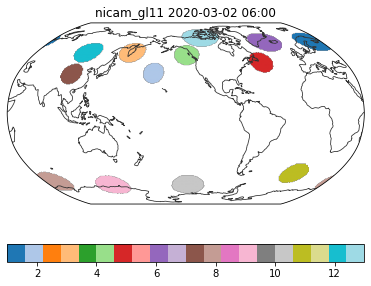

In [5]:
time_str = time_val.dt.strftime('%Y-%m-%d %H:%M').item()
title = f"{source} {time_str}"
img = egh.healpix_show(ETC_tag.where(ETC_tag > 0), cmap='tab20')
plt.title(title)
plt.colorbar(img, orientation='horizontal')

<Figure size 460.8x345.6 with 0 Axes>

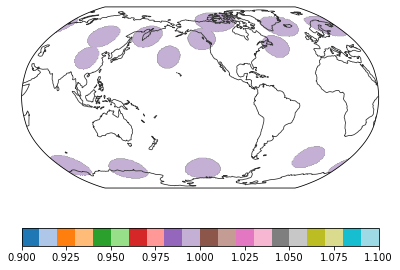

In [6]:
img = egh.healpix_show(ETC_binary.where(ETC_binary > 0), cmap='tab20')
plt.colorbar(img, orientation='horizontal')

<Figure size 460.8x345.6 with 0 Axes>

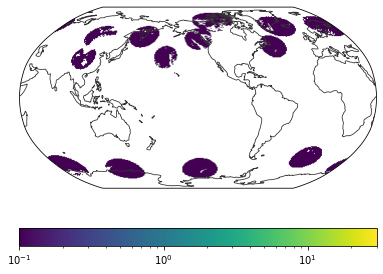

In [8]:
img = egh.healpix_show(pr, norm=mpl.colors.LogNorm(vmin=10e-2, vmax=30), cmap='viridis')
plt.colorbar(img, orientation='horizontal')